# Session 13 — Reversibility: training a 20M LLM without storing its activations

**Assignment:** train a ~20M-parameter LLM for 50M tokens at a batch size that fits; train it
again with a reversible residual stream at the same batch (and report which reversible variant
worked); then train reversibly again at the largest batch that fits. Report final loss, speed
(tokens/s), peak memory and other findings.

## The idea in one paragraph

An ordinary residual block computes `p_next = p + f(p)`. To backpropagate through it you must
have kept `p`, because you cannot recover `p` from `p_next` — getting it back would need
`f(p)`, which needs `p`. So every layer's activations are stored, and activation memory grows
with depth. A **reversible** rule changes what the block's output is added to so that the step
can be run backwards. The midpoint rule from Gal et al. (arXiv 2512.02056) is

`p[l+1] = p[l-1] + 2h·f(p[l])`   and therefore   `p[l-1] = p[l+1] − 2h·f(p[l])`.

Given the last two states you can rebuild every earlier one. The forward pass keeps only the
final pair; the backward pass walks down the stack, rebuilds each layer's input from its
output, reruns that one layer with gradients on, and backpropagates through it. Activation
memory stops depending on depth. The price is one extra forward pass per layer.

## What this notebook checks before believing anything

A reversible network that is subtly wrong still trains — just worse — so a loss curve alone
proves nothing. Three gates run before any long training run, and they are assertions that
fail the build:

1. **Gradient identity.** For each reversible variant, the custom backward (rebuild, rerun,
   backprop) must produce the same gradients as ordinary autograd through the *same*
   architecture with everything stored. Checked in float64 so any difference is a bug, not
   rounding.
2. **Reconstruction error**, layer by layer, in float32 and in the float16 autocast the runs
   actually use — rebuilt state against the state the forward pass really produced.
3. **Memory against depth.** Ordinary training memory should grow linearly with layers;
   reversible memory should be flat. That is the paper's Figure 3, reproduced here.

## Contents

0. Environment
1. Data — TinyStories and an 8,192-token BPE
2. The model and the residual rules
3. Gate 1: gradient identity
4. Gate 2: reconstruction error
5. Gate 3: memory against depth
6. Finding the batch sizes
7. The training loop
8. Run 1 — baseline
9. Run 2 — reversible variants at the same batch
10. Run 3 — the winning variant at its maximum batch
11. Results
12. What the trained models say about reconstruction
13. Write results

## 0. Environment

Every number in this notebook is tied to the device that produced it. A tokens/s or a peak
memory figure means nothing without the card next to it.

In [1]:
import os, sys, json, math, time, pathlib, urllib.request
# One allocator setting for every arm: fewer fragmentation-driven OOMs near the memory limit.
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F

T_START = time.perf_counter()
SMOKE = os.environ.get("S13_SMOKE") == "1"   # tiny everything, for a CPU dry run of the pipeline
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
AMP = DEVICE == "cuda"                       # fp16 autocast + GradScaler on GPU
ENV = {"device": DEVICE, "torch": torch.__version__, "smoke": SMOKE, "python": sys.version.split()[0]}
if DEVICE == "cuda":
    p = torch.cuda.get_device_properties(0)
    ENV |= {"gpu": p.name, "gpu_mem_gib": round(p.total_memory / 2**30, 2), "sm": f"{p.major}{p.minor}"}
    torch.backends.cuda.matmul.allow_tf32 = True
print(json.dumps(ENV, indent=2))

RESULTS = {"env": ENV}
pathlib.Path("assets").mkdir(exist_ok=True)
pathlib.Path("data").mkdir(exist_ok=True)

if DEVICE == "cuda" and p.major < 8:
    print("\nThis card has no bfloat16 (sm_%d%d). Every run below uses float16 autocast with a "
          "GradScaler, and keeps the residual stream itself in float32." % (p.major, p.minor))

{
  "device": "cuda",
  "torch": "2.5.1+cu121",
  "smoke": false,
  "python": "3.10.12",
  "gpu": "Tesla T4",
  "gpu_mem_gib": 14.56,
  "sm": "75"
}

This card has no bfloat16 (sm_75). Every run below uses float16 autocast with a GradScaler, and keeps the residual stream itself in float32.


## 1. Data — TinyStories and an 8,192-token BPE

**Why TinyStories.** A 20M-parameter model trained on 50M tokens is small and short. On web
text it would learn little beyond word frequencies and the loss curves of different arms would
be hard to tell apart. TinyStories (Eldan & Li, 2023) is simple enough that a model this size
learns real structure in 50M tokens, so differences between arms show up clearly.

**Why a custom 8,192-token vocabulary.** With GPT-2's 50,257-token vocabulary at width 256 the
embedding table alone would be 12.9M parameters — most of the "20M" would be a lookup table
and very little would be the transformer whose activations this assignment is about. A BPE
trained on the data itself keeps the embedding at 2.1M.

The GPT-4-generated V2 split is used. The notebook fetches only the byte range it needs (a
~240MB prefix of the 2.2GB file) and cuts it at a story boundary.

In [2]:
BASE = "https://huggingface.co/datasets/roneneldan/TinyStories/resolve/main/"
TRAIN_BYTES = 3_000_000 if SMOKE else 240_000_000
VALID_BYTES = 1_000_000 if SMOKE else 22_502_601
VOCAB = 8192
EOT = "<|endoftext|>"

def fetch(name, nbytes, dest):
    dest = pathlib.Path(dest)
    if dest.exists() and dest.stat().st_size >= nbytes - 1:
        return dest.read_bytes()
    req = urllib.request.Request(BASE + name, headers={"Range": f"bytes=0-{nbytes - 1}"})
    t = time.time()
    with urllib.request.urlopen(req) as r:
        raw = r.read()
    dest.write_bytes(raw)
    print(f"fetched {len(raw)/1e6:.1f} MB of {name} in {time.time()-t:.0f}s")
    return raw

def stories(raw):
    text = raw.decode("utf-8", errors="ignore")
    text = text[: text.rfind(EOT)]            # drop the partial story at the cut
    return [s.strip() for s in text.split(EOT) if s.strip()]

train_docs = stories(fetch("TinyStoriesV2-GPT4-train.txt", TRAIN_BYTES, "data/train_prefix.txt"))
valid_docs = stories(fetch("TinyStoriesV2-GPT4-valid.txt", VALID_BYTES, "data/valid.txt"))
print(f"{len(train_docs):,} training stories, {len(valid_docs):,} validation stories")

293,029 training stories, 27,629 validation stories


In [3]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders

TOK_PATH = pathlib.Path("assets/tokenizer.json")
if TOK_PATH.exists() and not SMOKE:
    tok = Tokenizer.from_file(str(TOK_PATH))
else:
    tok = Tokenizer(models.BPE())
    tok.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
    tok.decoder = decoders.ByteLevel()
    trainer = trainers.BpeTrainer(vocab_size=VOCAB, special_tokens=[EOT],
                                  initial_alphabet=pre_tokenizers.ByteLevel.alphabet())
    # trained on the first ~20MB of stories — plenty for an 8K vocabulary
    n = 0; sample = []
    for d in train_docs:
        sample.append(d); n += len(d)
        if n > 20_000_000: break
    tok.train_from_iterator(sample, trainer)
    if not SMOKE:
        tok.save(str(TOK_PATH))
EOT_ID = tok.token_to_id(EOT)
assert tok.get_vocab_size() == VOCAB, tok.get_vocab_size()
print("vocab", tok.get_vocab_size(), " sample:", tok.encode("Once upon a time, a little dog").tokens)

vocab 8192  sample: ['Once', 'Ġupon', 'Ġa', 'Ġtime', ',', 'Ġa', 'Ġlittle', 'Ġdog']


In [4]:
SEQ = 64 if SMOKE else 512
TRAIN_TOKENS = 200_000 if SMOKE else 50_000_000

def encode_to(docs, limit, path):
    path = pathlib.Path(path)
    if path.exists():
        arr = np.fromfile(path, dtype=np.uint16)
        if len(arr) >= limit: return arr
    out, n = [], 0
    for i in range(0, len(docs), 20_000):
        for e in tok.encode_batch(docs[i:i + 20_000]):
            ids = e.ids + [EOT_ID]; out.append(np.asarray(ids, dtype=np.uint16)); n += len(ids)
        if n >= limit: break
    arr = np.concatenate(out)
    arr.tofile(path)
    return arr

t = time.time()
# 2M spare tokens so every batch size's final partial step is still covered by real data
train_ids = encode_to(train_docs, TRAIN_TOKENS + 2_000_000, "data/train.u16")
valid_ids = encode_to(valid_docs, 10**9, "data/valid.u16")
del train_docs, valid_docs
chars_per_tok = None
print(f"encoded in {time.time()-t:.0f}s: {len(train_ids)/1e6:.2f}M train tokens, "
      f"{len(valid_ids)/1e6:.2f}M validation tokens")
assert len(train_ids) >= TRAIN_TOKENS + SEQ * 1024 or SMOKE, "not enough training text fetched"

RESULTS["data"] = {"dataset": "TinyStoriesV2-GPT4", "vocab": VOCAB, "seq_len": SEQ,
                   "train_tokens_available": int(len(train_ids)), "valid_tokens": int(len(valid_ids)),
                   "train_budget_tokens": TRAIN_TOKENS}

encoded in 3s: 55.23M train tokens, 5.42M validation tokens


**Fixed data order.** The training stream is cut into non-overlapping windows of `SEQ` tokens.
The windows are shuffled once, with a fixed seed, and every run consumes them in that same
order. Two runs at the same batch size therefore see identical batches; a run at a larger
batch sees the same token stream, grouped into fewer, larger steps.

In [5]:
N_WIN = (len(train_ids) - 1) // SEQ
WIN_ORDER = np.random.default_rng(1337).permutation(N_WIN)
train_t = torch.from_numpy(train_ids.astype(np.int64))
valid_t = torch.from_numpy(valid_ids.astype(np.int64))

def get_batch(step, B):
    w = WIN_ORDER[step * B:(step + 1) * B]
    idx = torch.from_numpy(w * SEQ)[:, None] + torch.arange(SEQ + 1)[None, :]
    chunk = train_t[idx]
    return chunk[:, :-1].to(DEVICE, non_blocking=True), chunk[:, 1:].to(DEVICE, non_blocking=True)

EVAL_SEQS = 64 if SMOKE else 1024          # 1024 × 512 = 524K held-out tokens per evaluation
def valid_batches(bs=32):
    for i in range(0, EVAL_SEQS, bs):
        idx = torch.arange(i, i + bs)[:, None] * SEQ + torch.arange(SEQ + 1)[None, :]
        chunk = valid_t[idx]
        yield chunk[:, :-1].to(DEVICE), chunk[:, 1:].to(DEVICE)

## 2. The model and the residual rules

A nanoGPT-style decoder: learned positions, pre-LayerNorm blocks, 4× GELU MLP, tied input and
output embeddings, PyTorch's `scaled_dot_product_attention` (which on this card uses the
memory-efficient kernel — no T×T score matrix is stored in any arm). **Dropout is zero in
every arm**, because a reversible backward reruns each block and a fresh dropout mask would
rebuild the wrong activations. **Weight decay is zero in every arm**, following the
instructor's stated restriction. Applying both to the baseline too means the residual rule is
the only thing that differs between arms.

Shape: width 256, 24 layers, 4 heads of 64, context 512. Deep and narrow on purpose:
reversibility saves memory in proportion to depth, so a deep model shows what it does.

The block function is the paper's eq. 2.5 — a whole pre-LN block without its outer skip:
`f(p) = a + MLP(LN₂(p + a))` with `a = Attn(LN₁(p))`. With the ordinary rule
`p ← p + f(p)` this is exactly the standard GPT block.

### The residual rules

Each reversible rule carries a *pair* of states and maps one pair to the next. The stack
starts from the pair (x, x), where x is the embedded input, and the model reads the second
state of the final pair.

| rule | forward | inverse | paper |
| --- | --- | --- | --- |
| `standard` | p ← p + f(p) | — (not invertible) | eq. 2.2 |
| `midpoint` | (u, v) → (v, u + 2h·f(v)) | u = w − 2h·f(v) | eq. 2.4 |
| `midpoint_a` | (u, v) → (v, a·u + (1−a)·v + h·f(v)) | u = (w − (1−a)·v − h·f(v)) / a | eq. 3.6 |
| `leapfrog` | (u, v) → (v, 2v − u + h²·f(v)) | u = 2v − w + h²·f(v) | eq. 2.6 |
| `hamiltonian` | q ← q + Attn(LN₁ p);  p ← p + MLP(LN₂ q) | p ← p − MLP(LN₂ q);  q ← q − Attn(LN₁ p) | eq. 2.8–2.9 |

**Which one is "Euler"?** The assignment says "mid-point, euler, etc", and the paper has no
variant literally named Euler. Two candidates: the paper says midpoint(a) "behaves in
expectation just like the forward Euler equation" (§3.2), and it calls the Hamiltonian scheme
one "resembling the symplectic Euler integrator" (§2.1). This notebook treats the
**Hamiltonian / symplectic-Euler** scheme as the Euler variant, because it is an Euler
integrator by construction, and it also runs midpoint(a) because that is the configuration
the lesson quotes from Lightning LM: **h = 0.25, a = 0.5**. The same h is used for every rule.

**A prediction before running anything.** Run the midpoint(a) inverse on a constant state and
it becomes `u = (w − (1−a)v)/a`: at a = 0.5, whatever error `w` carries is *doubled* at every
layer on the way back down. The paper's own stability analysis (§3.1) says forward-and-backward
stability needs |a| = 1. So midpoint(a) at a = 0.5 should rebuild its early layers badly —
roughly 2²⁴ ≈ 1.7×10⁷ times the rounding error at 24 layers. Gate 2 measures this.

In [6]:
CFG = dict(vocab=VOCAB, d=64 if SMOKE else 256, L=4 if SMOKE else 24,
           heads=4, T=SEQ)
H_STEP, A_BLEND = 0.25, 0.5

class Attn(nn.Module):
    def __init__(s, d, h):
        super().__init__(); s.h = h
        s.qkv = nn.Linear(d, 3 * d); s.o = nn.Linear(d, d)
    def forward(s, x):
        B, T, D = x.shape
        q, k, v = s.qkv(x).view(B, T, 3, s.h, D // s.h).permute(2, 0, 3, 1, 4)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        return s.o(y.transpose(1, 2).reshape(B, T, D))

class Block(nn.Module):
    def __init__(s, d, h):
        super().__init__()
        s.ln1, s.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        s.attn = Attn(d, h)
        s.mlp = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))
    def a(s, p): return s.attn(s.ln1(p))
    def m(s, q): return s.mlp(s.ln2(q))
    def f(s, p):
        a = s.a(p)
        return a + s.m(p + a)

# Residual rules. Block outputs come out of autocast as fp16; .float() keeps the residual
# stream itself in fp32 so rounding in the stream is fp32 rounding, not fp16.
def _f(b, v): return b.f(v).float()
RULES = {
    "midpoint": (lambda b, u, v: (v, u + 2 * H_STEP * _f(b, v)),
                 lambda b, v, w: (w - 2 * H_STEP * _f(b, v), v)),
    "midpoint_a": (lambda b, u, v: (v, A_BLEND * u + (1 - A_BLEND) * v + H_STEP * _f(b, v)),
                   lambda b, v, w: ((w - (1 - A_BLEND) * v - H_STEP * _f(b, v)) / A_BLEND, v)),
    "leapfrog": (lambda b, u, v: (v, 2 * v - u + H_STEP ** 2 * _f(b, v)),
                 lambda b, v, w: (2 * v - w + H_STEP ** 2 * _f(b, v), v)),
}
def _ham_fwd(b, q, p):
    q = q + b.a(p).float()
    return q, p + b.m(q).float()
def _ham_inv(b, q, p):
    p = p - b.m(q).float()
    return q - b.a(p).float(), p
RULES["hamiltonian"] = (_ham_fwd, _ham_inv)
REVERSIBLE = list(RULES)

def autocast():
    return torch.autocast("cuda", dtype=torch.float16, enabled=AMP)

class RevStack(torch.autograd.Function):
    """The reversible trunk. forward() runs every layer under no_grad and saves only the final
    pair of states. backward() walks down the stack: rebuild this layer's input pair from its
    output pair with the inverse rule, rerun this one layer with grad enabled, backpropagate
    through it (parameter gradients accumulate straight into .grad), move down a layer."""
    @staticmethod
    def forward(ctx, u, v, blocks, rule):
        fwd, _ = RULES[rule]
        with torch.no_grad(), autocast():
            for b in blocks:
                u, v = fwd(b, u, v)
        ctx.blocks, ctx.rule = blocks, rule
        ctx.save_for_backward(u, v)
        return u, v

    @staticmethod
    def backward(ctx, gu, gv):
        fwd, inv = RULES[ctx.rule]
        u, v = ctx.saved_tensors
        for b in reversed(ctx.blocks):
            with torch.no_grad(), autocast():
                u, v = inv(b, u, v)
            u = u.detach().requires_grad_(); v = v.detach().requires_grad_()
            with torch.enable_grad(), autocast():
                ou, ov = fwd(b, u, v)
            torch.autograd.backward((ou, ov), (gu, gv))
            gu, gv = u.grad, v.grad
            u, v = u.detach(), v.detach()
        return gu, gv, None, None

class GPT(nn.Module):
    def __init__(s, vocab, d, L, heads, T, rule="standard", store=False):
        """rule: 'standard' or one of RULES. store=True runs a reversible rule with ordinary
        autograd (everything kept) — the same function, used as the oracle in Gate 1."""
        super().__init__()
        s.rule, s.store, s.L = rule, store, L
        s.wte, s.wpe = nn.Embedding(vocab, d), nn.Embedding(T, d)
        s.blocks = nn.ModuleList(Block(d, heads) for _ in range(L))
        s.lnf = nn.LayerNorm(d)
        s.head = nn.Linear(d, vocab, bias=False)
        s.head.weight = s.wte.weight                           # tied
        s.apply(s._init)
        for n, prm in s.named_parameters():                    # GPT-2 scaled init on residual outputs
            if n.endswith("attn.o.weight") or n.endswith("mlp.2.weight"):
                nn.init.normal_(prm, 0.0, 0.02 / math.sqrt(2 * L))

    @staticmethod
    def _init(m):
        if isinstance(m, (nn.Linear, nn.Embedding)): nn.init.normal_(m.weight, 0.0, 0.02)
        if isinstance(m, nn.Linear) and m.bias is not None: nn.init.zeros_(m.bias)

    def embed(s, idx):
        return s.wte(idx) + s.wpe(torch.arange(idx.shape[1], device=idx.device))

    def trunk(s, x):
        if s.rule == "standard":
            with autocast():
                for b in s.blocks: x = x + b.f(x).float()
            return x
        if s.store:
            fwd, _ = RULES[s.rule]; u = v = x
            with autocast():
                for b in s.blocks: u, v = fwd(b, u, v)
            return v
        return RevStack.apply(x, x, list(s.blocks), s.rule)[1]

    def forward(s, idx, targets=None):
        y = s.trunk(s.embed(idx))
        with autocast():
            logits = s.head(s.lnf(y))
        if targets is None: return logits, None
        return logits, F.cross_entropy(logits.float().view(-1, logits.size(-1)), targets.reshape(-1))

def n_params(m):
    return sum(p.numel() for p in m.parameters())

_m = GPT(**CFG)
N_PARAMS = n_params(_m)
N_NONEMB = N_PARAMS - _m.wte.weight.numel() - _m.wpe.weight.numel()
print(f"parameters: {N_PARAMS/1e6:.2f}M total (tied embeddings), "
      f"{N_NONEMB/1e6:.2f}M in the transformer blocks, "
      f"{_m.wte.weight.numel()/1e6:.2f}M token embedding, {_m.wpe.weight.numel()/1e6:.2f}M positions")
assert SMOKE or 19e6 <= N_PARAMS <= 22e6, "the assignment asks for a ~20M model"
del _m
RESULTS["model"] = {**CFG, "params": N_PARAMS, "params_M": N_PARAMS / 1e6,
                    "params_blocks_M": N_NONEMB / 1e6, "h": H_STEP, "a": A_BLEND,
                    "dropout": 0.0, "weight_decay": 0.0}

parameters: 21.18M total (tied embeddings), 18.95M in the transformer blocks, 2.10M token embedding, 0.13M positions


## 3. Gate 1 — gradient identity

For every reversible rule: build the model twice with identical weights, once running the
custom reversible backward and once with `store=True` (ordinary autograd through the same
function). Compare every parameter's gradient. This runs in float64 on the CPU, so the only
possible sources of difference are a bug or the rounding of the rebuild itself.

A small model (width 64, 24 layers — the depth is what matters) keeps this quick.

In [7]:
def grad_identity(rule, L=24, d=64, seed=0):
    global AMP
    amp_was, AMP = AMP, False
    torch.manual_seed(seed)
    kw = dict(vocab=512, d=d, L=L, heads=4, T=32)
    ref = GPT(**kw, rule=rule, store=True).double()
    rev = GPT(**kw, rule=rule).double(); rev.load_state_dict(ref.state_dict())
    idx = torch.randint(0, 512, (2, 32)); tgt = torch.randint(0, 512, (2, 32))
    l_ref = ref(idx, tgt)[1]; l_ref.backward()
    l_rev = rev(idx, tgt)[1]; l_rev.backward()
    rel = max(((a.grad - b.grad).abs().max() / b.grad.abs().max()).item()
              for a, b in zip(rev.parameters(), ref.parameters()))
    AMP = amp_was
    return abs(l_ref.item() - l_rev.item()), rel

GATE1 = {}
for rule in REVERSIBLE:
    dl, rel = grad_identity(rule)
    GATE1[rule] = {"loss_diff": dl, "max_rel_grad_diff": rel}
    print(f"{rule:12s} loss identical: {dl == 0.0}   max relative gradient difference {rel:.2e}")

# All exact rules must agree to float64 rounding. midpoint_a is held to a looser bound, and
# its excess is the point of Gate 2, not a bug: its inverse amplifies rounding ~2x per layer.
for rule in ["midpoint", "leapfrog", "hamiltonian"]:
    assert GATE1[rule]["max_rel_grad_diff"] < 1e-10, rule
assert GATE1["midpoint_a"]["max_rel_grad_diff"] < 1e-5
assert all(g["loss_diff"] == 0.0 for g in GATE1.values())
RESULTS["gate1"] = GATE1
print("\nGate 1 passed: the reversible backward computes the same gradients as ordinary autograd.")

midpoint     loss identical: True   max relative gradient difference 2.20e-16


midpoint_a   loss identical: True   max relative gradient difference 4.28e-09


leapfrog     loss identical: True   max relative gradient difference 3.41e-15


hamiltonian  loss identical: True   max relative gradient difference 2.13e-16

Gate 1 passed: the reversible backward computes the same gradients as ordinary autograd.


## 4. Gate 2 — reconstruction error, layer by layer

Now at full size (width 256, 24 layers), on the training device, in the precision the runs
use. Run the stack forward and keep every state (for measurement only), then run the inverse
from the top and compare each rebuilt state with the real one. Reported as the largest
absolute error relative to the typical size of the state.

In [8]:
@torch.no_grad()
def recon_profile(model, idx):
    """Relative error of the rebuilt input to each layer, from the top of the stack down."""
    fwd, inv = RULES[model.rule]
    x = model.embed(idx).float()
    states = [(x, x)]; u = v = x
    with autocast():
        for b in model.blocks:
            u, v = fwd(b, u, v); states.append((u, v))
        errs = []
        for i in reversed(range(model.L)):
            u, v = inv(model.blocks[i], u, v)
            tu, tv = states[i]
            scale = tv.abs().mean().item()
            errs.append(max((u - tu).abs().max().item(), (v - tv).abs().max().item()) / scale)
    return errs[::-1]      # errs[i] = error in the rebuilt input to layer i

torch.manual_seed(0)
probe = torch.randint(0, VOCAB, (8, SEQ), device=DEVICE)
GATE2 = {}
for rule in REVERSIBLE:
    torch.manual_seed(1)
    m = GPT(**CFG, rule=rule).to(DEVICE).eval()
    AMP_saved = AMP
    GATE2[rule] = {}
    for prec in (["fp32", "fp16"] if DEVICE == "cuda" else ["fp32"]):
        AMP = prec == "fp16"
        GATE2[rule][prec] = recon_profile(m, probe)
    AMP = AMP_saved
    row = "  ".join(f"{k}: input {v[0]:.1e}, last layer {v[-1]:.1e}" for k, v in GATE2[rule].items())
    print(f"{rule:12s} {row}")
    del m

for rule in ["midpoint", "leapfrog", "hamiltonian"]:
    assert max(GATE2[rule]["fp32"]) < 1e-3, rule
RESULTS["gate2_init"] = {r: {k: {"input": v[0], "max": max(v)} for k, v in d.items()} for r, d in GATE2.items()}

midpoint     fp32: input 4.0e-06, last layer 4.7e-07  fp16: input 4.4e-03, last layer 2.4e-07


midpoint_a   fp32: input 1.1e+01, last layer 1.2e-06  fp16: input 4.6e+03, last layer 6.0e-07


leapfrog     fp32: input 7.8e-05, last layer 5.2e-07  fp16: input 7.1e-03, last layer 2.6e-07


hamiltonian  fp32: input 1.3e-05, last layer 4.6e-07  fp16: input 8.2e-03, last layer 1.2e-04


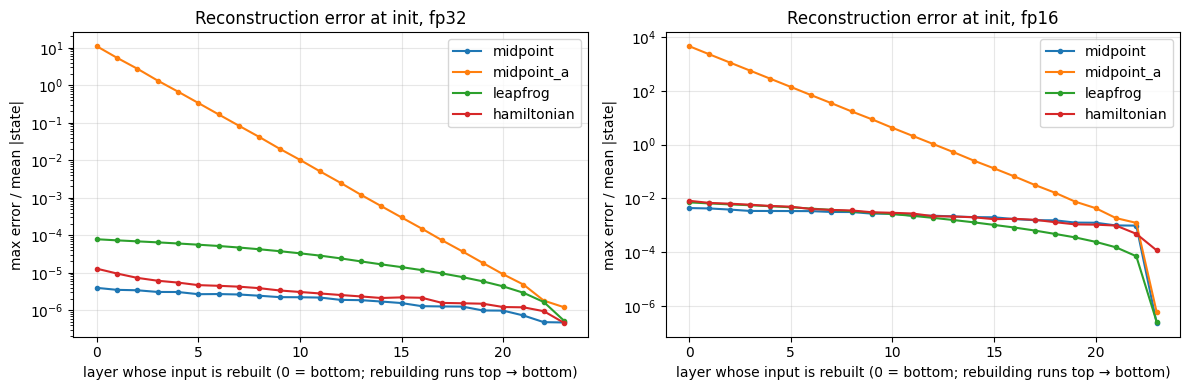

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, axes = plt.subplots(1, len(GATE2["midpoint"]), figsize=(6 * len(GATE2["midpoint"]), 4), squeeze=False)
for ax, prec in zip(axes[0], GATE2["midpoint"]):
    for rule in REVERSIBLE:
        ax.semilogy(range(CFG["L"]), np.maximum(GATE2[rule][prec], 1e-12), marker="o", ms=3, label=rule)
    ax.set_xlabel("layer whose input is rebuilt (0 = bottom; rebuilding runs top → bottom)")
    ax.set_ylabel("max error / mean |state|"); ax.set_title(f"Reconstruction error at init, {prec}")
    ax.grid(alpha=.3); ax.legend()
fig.tight_layout(); fig.savefig("assets/recon_error_init.png", dpi=120); plt.show()

## 5. Gate 3 — memory against depth

One training step at a fixed batch, for 4 to 48 layers, ordinary against reversible
(midpoint; the other rules store the same two states). Peak memory is
`torch.cuda.max_memory_allocated()` after a reset. Ordinary memory should rise by a fixed
amount per layer — that layer's stored activations — and reversible memory should barely move.

L= 4  standard 1.13 GiB   reversible 0.85 GiB


L= 8  standard 1.45 GiB   reversible 0.89 GiB


L=16  standard 2.10 GiB   reversible 0.96 GiB


L=24  standard 2.75 GiB   reversible 1.03 GiB


L=32  standard 3.39 GiB   reversible 1.10 GiB


L=48  standard 4.69 GiB   reversible 1.24 GiB

memory per extra layer: standard 82.8 MiB, reversible 9.0 MiB (batch 16 × 512 tokens)
one layer's weights + grads + Adam state at 16 B/param: 12.1 MiB — the part reversibility cannot remove
stored activations per layer = the difference, 73.8 MiB = 36.9 bytes per token per hidden unit (lesson §1, after Korthikanti et al.: ~34)


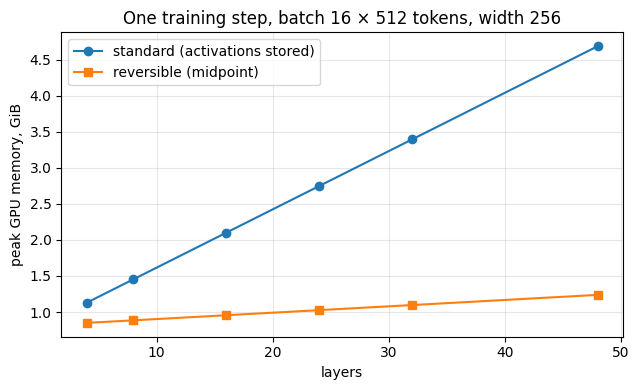

In [10]:
def one_step_peak(rule, B, L=None, steps=2):
    cfg = dict(CFG, L=L or CFG["L"])
    torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    m = GPT(**cfg, rule=rule).to(DEVICE)
    opt = torch.optim.AdamW(m.parameters(), lr=1e-4, weight_decay=0.0, fused=True)
    sc = torch.amp.GradScaler("cuda")
    x = torch.randint(0, VOCAB, (B, SEQ), device=DEVICE)
    torch.cuda.synchronize(); t = time.perf_counter()
    for _ in range(steps):
        loss = m(x, x)[1]
        sc.scale(loss).backward(); sc.step(opt); sc.update(); opt.zero_grad(set_to_none=True)
    torch.cuda.synchronize()
    dt = (time.perf_counter() - t) / steps
    peak = torch.cuda.max_memory_allocated() / 2**30
    del m, opt, x, loss; torch.cuda.empty_cache()
    return peak, dt

DEPTH = {}
if DEVICE == "cuda":
    B_DEPTH = 16
    for L in [4, 8, 16, 24, 32, 48]:
        DEPTH[L] = {r: one_step_peak(r, B_DEPTH, L)[0] for r in ["standard", "midpoint"]}
        print(f"L={L:2d}  standard {DEPTH[L]['standard']:.2f} GiB   reversible {DEPTH[L]['midpoint']:.2f} GiB")
    Ls = sorted(DEPTH)
    slope_std = np.polyfit(Ls, [DEPTH[L]["standard"] for L in Ls], 1)[0]
    slope_rev = np.polyfit(Ls, [DEPTH[L]["midpoint"] for L in Ls], 1)[0]
    per_layer_state = sum(p.numel() for p in Block(CFG["d"], CFG["heads"]).parameters()) * 16 / 2**20
    act_per_layer = (slope_std - slope_rev) * 2**30                     # bytes of stored activations
    bytes_per_tok_hidden = act_per_layer / (B_DEPTH * SEQ * CFG["d"])
    print(f"\nmemory per extra layer: standard {slope_std*1024:.1f} MiB, reversible {slope_rev*1024:.1f} MiB "
          f"(batch {B_DEPTH} × {SEQ} tokens)")
    print(f"one layer's weights + grads + Adam state at 16 B/param: {per_layer_state:.1f} MiB — the part "
          f"reversibility cannot remove")
    print(f"stored activations per layer = the difference, {act_per_layer/2**20:.1f} MiB "
          f"= {bytes_per_tok_hidden:.1f} bytes per token per hidden unit (lesson §1, after Korthikanti et al.: ~34)")
    # The reversible stack's per-layer growth must be model state, not activations:
    assert SMOKE or slope_rev * 1024 < 1.5 * per_layer_state
    assert SMOKE or 20 < bytes_per_tok_hidden < 60
    RESULTS["depth"] = {"batch": B_DEPTH, "peak_gib": {str(L): v for L, v in DEPTH.items()},
                        "mib_per_layer_standard": slope_std * 1024, "mib_per_layer_reversible": slope_rev * 1024,
                        "mib_per_layer_state": per_layer_state, "act_mib_per_layer": act_per_layer / 2**20,
                        "bytes_per_token_hidden": bytes_per_tok_hidden,
                        "at_4": DEPTH[4], "at_24": DEPTH[24], "at_48": DEPTH[48]}

    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.plot(Ls, [DEPTH[L]["standard"] for L in Ls], "o-", label="standard (activations stored)")
    ax.plot(Ls, [DEPTH[L]["midpoint"] for L in Ls], "s-", label="reversible (midpoint)")
    ax.set_xlabel("layers"); ax.set_ylabel("peak GPU memory, GiB")
    ax.set_title(f"One training step, batch {B_DEPTH} × {SEQ} tokens, width {CFG['d']}")
    ax.grid(alpha=.3); ax.legend(); fig.tight_layout(); fig.savefig("assets/memory_vs_depth.png", dpi=120); plt.show()
else:
    print("no GPU: Gate 3 needs CUDA memory statistics, skipped in this dry run")

## 6. Finding the batch sizes

"Fix batch size that you can run" — for the baseline, the largest batch that fits is found by
trying two real training steps (doubling, then bisecting in steps of 8), catching out-of-memory.
The batch actually used keeps a 10% safety margin, rounded down to a multiple of 8, because a
long run's allocator fragmentation can need a little more than one isolated step does.

The same search is repeated for the reversible model; that is the batch Run 3 uses.

In [11]:
def fits(rule, B):
    # two steps, not one: Adam allocates its state at the end of the first step, so a batch
    # that survives one step can still run out of memory on the second (hit in testing)
    try:
        one_step_peak(rule, B, steps=2); return True
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache(); return False

def max_batch(rule):
    lo, hi = 0, 8
    while fits(rule, hi):
        lo, hi = hi, hi * 2
    while hi - lo > 8:
        mid = (lo + hi) // 2 // 8 * 8
        lo, hi = (mid, hi) if fits(rule, mid) else (lo, mid)
    return lo

def with_margin(b): return max(8, int(b * 0.9) // 8 * 8)

if DEVICE == "cuda":
    BMAX = {"standard": max_batch("standard"), "reversible": max_batch("midpoint")}
    B_FIXED = with_margin(BMAX["standard"])
    B_REV_MAX = with_margin(BMAX["reversible"])
else:
    BMAX = {"standard": 8, "reversible": 32}; B_FIXED, B_REV_MAX = 8, 32
print(f"largest batch that completes a step: standard {BMAX['standard']}, reversible {BMAX['reversible']} "
      f"({BMAX['reversible'] / BMAX['standard']:.2f}×)")
print(f"batches used: fixed B = {B_FIXED} (Runs 1–2), reversible max B = {B_REV_MAX} (Run 3)")
RESULTS["batch"] = {"max_standard": BMAX["standard"], "max_reversible": BMAX["reversible"],
                    "ratio": BMAX["reversible"] / BMAX["standard"],
                    "fixed": B_FIXED, "rev_max_used": B_REV_MAX}

largest batch that completes a step: standard 88, reversible 288 (3.27×)
batches used: fixed B = 72 (Runs 1–2), reversible max B = 256 (Run 3)


**Where the reversible model's memory goes at its maximum batch.** With the trunk's
activations gone, what is left per sequence is the two boundary states (tiny) and the output
layer: 512 positions × 8,192 logits, held in float16, upcast to float32 for the loss, plus the
gradient of all that. The measurement below splits one reversible step's peak into those
parts.

In [12]:
if DEVICE == "cuda":
    b = 16
    peak_rev, _ = one_step_peak("midpoint", b)
    logits_bytes = b * SEQ * VOCAB * (2 + 4 + 4)                # fp16 logits, fp32 upcast, fp32 grad
    state_bytes = 2 * b * SEQ * CFG["d"] * 4                     # the two saved fp32 states
    fixed_bytes = N_PARAMS * 16                                  # fp32 weights+grads+Adam m,v
    print(f"reversible step at batch {b}: peak {peak_rev:.2f} GiB")
    print(f"  model state (16 B/param)        {fixed_bytes/2**30:6.2f} GiB  (fixed)")
    print(f"  output logits + loss, estimate  {logits_bytes/2**30:6.2f} GiB  ({logits_bytes/b/2**20:.0f} MiB per sequence)")
    print(f"  saved boundary states           {state_bytes/2**30:6.3f} GiB  ({state_bytes/b/2**20:.1f} MiB per sequence)")
    RESULTS["rev_memory_breakdown"] = {"batch": b, "peak_gib": peak_rev, "state_gib": fixed_bytes / 2**30,
                                       "logits_mib_per_seq": logits_bytes / b / 2**20,
                                       "boundary_mib_per_seq": state_bytes / b / 2**20}

reversible step at batch 16: peak 1.03 GiB
  model state (16 B/param)          0.32 GiB  (fixed)
  output logits + loss, estimate    0.62 GiB  (40 MiB per sequence)
  saved boundary states            0.016 GiB  (1.0 MiB per sequence)


## 7. The training loop

Identical for every run except the residual rule, the batch size and (Run 3 only) the learning
rate:

- AdamW, β = (0.9, 0.95), **weight decay 0**, gradient clipping at 1.0.
- Learning rate 1e-3, linear warm-up over the first 3% of steps, cosine decay to 10%.
- float16 autocast with a dynamic GradScaler; residual stream in float32.
- Exactly as many steps as it takes to reach 50M tokens at that batch size.
- Validation loss on 1,024 held-out sequences (524K tokens) ten times per run.

**Speed** is steady-state tokens per second: the time of every training step after the first
20, excluding evaluation, with the GPU synchronised before each clock read. **Peak memory** is
`max_memory_allocated` over the whole run (reset at its start); `max_memory_reserved` — what
the caching allocator actually held — is recorded next to it.

In [13]:
LR = 1e-3
HOURLY_USD = 0.828     # g4dn.2xlarge on-demand, ap-south-1 (Mumbai), Linux; AWS Pricing API 2026-09-25

def lr_at(step, total, peak):
    warm = max(1, int(0.03 * total))
    if step < warm: return peak * (step + 1) / warm
    prog = (step - warm) / max(1, total - warm)
    return peak * (0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * prog)))

@torch.no_grad()
def evaluate(model):
    model.eval(); tot, n = 0.0, 0
    for x, y in valid_batches():
        tot += model(x, y)[1].item(); n += 1
    model.train(); return tot / n

def train(name, rule, B, lr=LR, tokens=TRAIN_TOKENS, seed=1234, keep_model=True):
    torch.manual_seed(seed)
    model = GPT(**CFG, rule=rule).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.95), weight_decay=0.0,
                            fused=DEVICE == "cuda")
    scaler = torch.amp.GradScaler("cuda", enabled=AMP)
    steps = math.ceil(tokens / (B * SEQ))
    evals_at = set(np.linspace(0, steps - 1, 10).astype(int).tolist())
    if DEVICE == "cuda":
        torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    log = {"step": [], "tokens": [], "loss": [], "grad_norm": [], "lr": []}
    evals = {"step": [], "tokens": [], "val_loss": []}
    run_time, timed_tokens, skipped, t_wall = 0.0, 0, 0, time.perf_counter()
    pending = []
    for step in range(steps):
        for g in opt.param_groups: g["lr"] = lr_at(step, steps, lr)
        x, y = get_batch(step, B)
        if DEVICE == "cuda": torch.cuda.synchronize()
        t0 = time.perf_counter()
        loss = model(x, y)[1]
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        gn = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt); scaler.update(); opt.zero_grad(set_to_none=True)
        if DEVICE == "cuda": torch.cuda.synchronize()
        if step >= 20:
            run_time += time.perf_counter() - t0; timed_tokens += B * SEQ
        pending.append((step, loss.detach(), gn.detach()))
        if step % 10 == 0 or step == steps - 1:
            for s_, l_, g_ in pending:
                log["step"].append(s_); log["tokens"].append((s_ + 1) * B * SEQ)
                log["loss"].append(l_.item()); log["grad_norm"].append(g_.item())
                log["lr"].append(lr_at(s_, steps, lr))
            pending = []
            if not math.isfinite(log["loss"][-1]):
                print(f"  {name}: loss is {log['loss'][-1]} at step {step} — stopping this run")
                break
        if step in evals_at:
            v = evaluate(model)
            evals["step"].append(step); evals["tokens"].append((step + 1) * B * SEQ); evals["val_loss"].append(v)
            msg = (f"  {name:22s} step {step+1:5d}/{steps}  train {log['loss'][-1]:.3f}  val {v:.3f}  "
                   f"lr {lr_at(step, steps, lr):.2e}")
            print(msg, flush=True)
            with open("data/progress.txt", "a") as fh:     # live progress while the kernel runs
                fh.write(time.strftime("%H:%M:%S ") + msg + "\n")
    wall = time.perf_counter() - t_wall
    tail = log["loss"][-max(1, len(log["loss"]) // 20):]           # last 5% of logged steps
    res = {"name": name, "rule": rule, "batch": B, "lr": lr, "steps": steps,
           "tokens_trained": steps * B * SEQ,
           "final_val_loss": evals["val_loss"][-1] if evals["val_loss"] else float("nan"),
           "final_train_loss": float(np.mean(tail)),
           "tokens_per_s": timed_tokens / run_time if run_time else float("nan"),
           "wall_s": wall, "wall_min": wall / 60,
           "cost_usd": wall / 3600 * HOURLY_USD,
           "finite": all(math.isfinite(l) for l in log["loss"]),
           "log": log, "evals": evals}
    if DEVICE == "cuda":
        res["peak_alloc_gib"] = torch.cuda.max_memory_allocated() / 2**30
        res["peak_reserved_gib"] = torch.cuda.max_memory_reserved() / 2**30
    print(f"  → {name}: val {res['final_val_loss']:.4f}, {res['tokens_per_s']/1e3:.1f}K tok/s, "
          f"peak {res.get('peak_alloc_gib', float('nan')):.2f} GiB, {res['wall_min']:.1f} min")
    if keep_model:
        MODELS[name] = {k: v.detach().cpu() for k, v in model.state_dict().items()}
    del model, opt
    if DEVICE == "cuda": torch.cuda.empty_cache()
    return res

RUNS, MODELS = {}, {}

## 8. Run 1 — baseline at the fixed batch

The ordinary residual transformer, at the largest batch that fits with the safety margin.

In [14]:
RUNS["baseline"] = train("baseline", "standard", B_FIXED)

  baseline               step     1/1357  train 9.083  val 8.707  lr 2.50e-05


  baseline               step   151/1357  train 3.675  val 3.676  lr 9.85e-04


  baseline               step   302/1357  train 2.913  val 2.911  lr 9.16e-04


  baseline               step   453/1357  train 2.566  val 2.495  lr 8.00e-04


  baseline               step   603/1357  train 2.284  val 2.252  lr 6.53e-04


...

  baseline               step   905/1357  train 1.944  val 1.979  lr 3.38e-04


  baseline               step  1055/1357  train 1.903  val 1.908  lr 2.13e-04


  baseline               step  1206/1357  train 1.902  val 1.858  lr 1.29e-04


  baseline               step  1357/1357  train 1.859  val 1.829  lr 1.00e-04


  → baseline: val 1.8289, 58.9K tok/s, peak 11.34 GiB, 14.7 min


## 9. Run 2 — reversible variants at the same batch

Same model, same data in the same order, same batch, same learning-rate schedule. Only the
residual rule changes. Each variant runs the full 50M tokens.

In [15]:
RUNS["rev_midpoint"] = train("rev_midpoint", "midpoint", B_FIXED)

  rev_midpoint           step     1/1357  train 9.060  val 8.807  lr 2.50e-05


  rev_midpoint           step   151/1357  train 3.551  val 3.559  lr 9.85e-04


  rev_midpoint           step   302/1357  train 2.821  val 2.821  lr 9.16e-04


  rev_midpoint           step   453/1357  train 2.482  val 2.415  lr 8.00e-04


  rev_midpoint           step   603/1357  train 2.217  val 2.183  lr 6.53e-04


...

  rev_midpoint           step   905/1357  train 1.910  val 1.943  lr 3.38e-04


  rev_midpoint           step  1055/1357  train 1.872  val 1.872  lr 2.13e-04


  rev_midpoint           step  1206/1357  train 1.870  val 1.827  lr 1.29e-04


  rev_midpoint           step  1357/1357  train 1.833  val 1.799  lr 1.00e-04


  → rev_midpoint: val 1.7985, 36.5K tok/s, peak 3.72 GiB, 23.4 min


In [16]:
RUNS["rev_hamiltonian"] = train("rev_hamiltonian", "hamiltonian", B_FIXED)

  rev_hamiltonian        step     1/1357  train 9.070  val 8.696  lr 2.50e-05


  rev_hamiltonian        step   151/1357  train 3.595  val 3.615  lr 9.85e-04


  rev_hamiltonian        step   302/1357  train 2.936  val 2.922  lr 9.16e-04


  rev_hamiltonian        step   453/1357  train 2.569  val 2.500  lr 8.00e-04


  rev_hamiltonian        step   603/1357  train 2.295  val 2.266  lr 6.53e-04


...

  rev_hamiltonian        step   905/1357  train 1.988  val 2.028  lr 3.38e-04


  rev_hamiltonian        step  1055/1357  train 1.957  val 1.959  lr 2.13e-04


  rev_hamiltonian        step  1206/1357  train 1.965  val 1.917  lr 1.29e-04


  rev_hamiltonian        step  1357/1357  train 1.922  val 1.890  lr 1.00e-04


  → rev_hamiltonian: val 1.8898, 37.5K tok/s, peak 3.72 GiB, 22.7 min


In [17]:
RUNS["rev_midpoint_a"] = train("rev_midpoint_a", "midpoint_a", B_FIXED)

  rev_midpoint_a         step     1/1357  train 9.074  val 8.948  lr 2.50e-05


  rev_midpoint_a         step   151/1357  train 5.692  val 5.715  lr 9.85e-04


  rev_midpoint_a         step   302/1357  train 5.522  val 5.519  lr 9.16e-04


  rev_midpoint_a         step   453/1357  train 5.167  val 5.130  lr 8.00e-04


  rev_midpoint_a         step   603/1357  train 4.708  val 4.683  lr 6.53e-04


...

  rev_midpoint_a         step   905/1357  train 4.691  val 4.729  lr 3.38e-04


  rev_midpoint_a         step  1055/1357  train 4.634  val 4.660  lr 2.13e-04


  rev_midpoint_a         step  1206/1357  train 4.556  val 4.530  lr 1.29e-04


  rev_midpoint_a         step  1357/1357  train 4.483  val 4.431  lr 1.00e-04


  → rev_midpoint_a: val 4.4308, 34.0K tok/s, peak 3.72 GiB, 25.1 min


In [18]:
RUNS["rev_leapfrog"] = train("rev_leapfrog", "leapfrog", B_FIXED)

  rev_leapfrog           step     1/1357  train 9.071  val 8.824  lr 2.50e-05


  rev_leapfrog           step   151/1357  train 3.348  val 3.348  lr 9.85e-04


  rev_leapfrog           step   302/1357  train 2.662  val 2.652  lr 9.16e-04


  rev_leapfrog           step   453/1357  train 2.389  val 2.322  lr 8.00e-04


  rev_leapfrog           step   603/1357  train 2.157  val 2.126  lr 6.53e-04


...

  rev_leapfrog           step   905/1357  train 1.856  val 1.895  lr 3.38e-04


  rev_leapfrog           step  1055/1357  train 1.826  val 1.833  lr 2.13e-04


  rev_leapfrog           step  1206/1357  train 1.830  val 1.791  lr 1.29e-04


  rev_leapfrog           step  1357/1357  train 1.794  val 1.766  lr 1.00e-04


  → rev_leapfrog: val 1.7664, 34.4K tok/s, peak 3.72 GiB, 24.8 min


### Which variant worked?

The verdict is computed, not chosen: the variant with the lowest final validation loss among
those whose loss stayed finite throughout. The loss curves are plotted in §11 so the
trajectory, not just the endpoint, can be judged.

In [19]:
VARIANTS = [k for k in RUNS if k.startswith("rev_")]
ok = [k for k in VARIANTS if RUNS[k]["finite"]]
WINNER = min(ok, key=lambda k: RUNS[k]["final_val_loss"])
WINNER_RULE = RUNS[WINNER]["rule"]
for k in VARIANTS:
    r = RUNS[k]
    print(f"{k:18s} val {r['final_val_loss']:.4f}  (baseline {RUNS['baseline']['final_val_loss']:.4f}, "
          f"Δ {r['final_val_loss'] - RUNS['baseline']['final_val_loss']:+.4f})")
print(f"\nwinner: {WINNER_RULE}")

rev_midpoint       val 1.7985  (baseline 1.8289, Δ -0.0304)
rev_hamiltonian    val 1.8898  (baseline 1.8289, Δ +0.0609)
rev_midpoint_a     val 4.4308  (baseline 1.8289, Δ +2.6019)
rev_leapfrog       val 1.7664  (baseline 1.8289, Δ -0.0625)

winner: leapfrog


## 10. Run 3 — the winning variant at its maximum batch

Now the memory the reversible model saved is spent on batch size. The token budget is still
50M, so a larger batch means fewer steps. The learning rate is scaled by √(B_max / B_fixed),
the usual rule for Adam, capped at 3e-3. That keeps the comparison honest in one direction —
the larger batch is not handicapped by a learning rate tuned for the smaller one — but it is a
rule of thumb, not a tuned value, and the loss difference against Runs 1–2 mixes the effect of
batch size with the effect of fewer steps. Speed and memory are the clean comparisons here.

In [20]:
LR_MAX = min(3e-3, LR * math.sqrt(B_REV_MAX / B_FIXED))
print(f"batch {B_FIXED} → {B_REV_MAX},  lr {LR:.1e} → {LR_MAX:.2e}")
RUNS["rev_maxbatch"] = train("rev_maxbatch", WINNER_RULE, B_REV_MAX, lr=LR_MAX)

batch 72 → 256,  lr 1.0e-03 → 1.89e-03


  rev_maxbatch           step     1/382  train 9.070  val 8.433  lr 1.71e-04


  rev_maxbatch           step    43/382  train 4.480  val 4.369  lr 1.86e-03


  rev_maxbatch           step    85/382  train 3.927  val 3.890  lr 1.73e-03


  rev_maxbatch           step   128/382  train 3.758  val 3.698  lr 1.51e-03


...

  rev_maxbatch           step   255/382  train 3.041  val 2.990  lr 6.40e-04


  rev_maxbatch           step   297/382  train 2.881  val 2.859  lr 4.04e-04


  rev_maxbatch           step   339/382  train 2.798  val 2.764  lr 2.47e-04


  rev_maxbatch           step   382/382  train 2.704  val 2.701  lr 1.89e-04


  → rev_maxbatch: val 2.7011, 35.0K tok/s, peak 12.57 GiB, 24.4 min


## 11. Results

In [21]:
base = RUNS["baseline"]
print(f"{'run':18s} {'rule':12s} {'batch':>5s} {'steps':>6s} {'val loss':>9s} {'train':>7s} "
      f"{'tok/s':>8s} {'vs base':>7s} {'peak GiB':>8s} {'min':>6s} {'$':>6s}")
for k, r in RUNS.items():
    print(f"{k:18s} {r['rule']:12s} {r['batch']:5d} {r['steps']:6d} {r['final_val_loss']:9.4f} "
          f"{r['final_train_loss']:7.4f} {r['tokens_per_s']:8.0f} {r['tokens_per_s']/base['tokens_per_s']:7.2f} "
          f"{r.get('peak_alloc_gib', float('nan')):8.2f} {r['wall_min']:6.1f} {r['cost_usd']:6.3f}")

run                rule         batch  steps  val loss   train    tok/s vs base peak GiB    min      $
baseline           standard        72   1357    1.8289  1.8424    58938    1.00    11.34   14.7  0.202
rev_midpoint       midpoint        72   1357    1.7985  1.8115    36511    0.62     3.72   23.4  0.322
rev_hamiltonian    hamiltonian     72   1357    1.8898  1.9030    37497    0.64     3.72   22.7  0.314
rev_midpoint_a     midpoint_a      72   1357    4.4308  4.4566    33972    0.58     3.72   25.1  0.347
rev_leapfrog       leapfrog        72   1357    1.7664  1.7778    34411    0.58     3.72   24.8  0.342
rev_maxbatch       leapfrog       256    382    2.7011  2.7251    34992    0.59    12.57   24.4  0.337


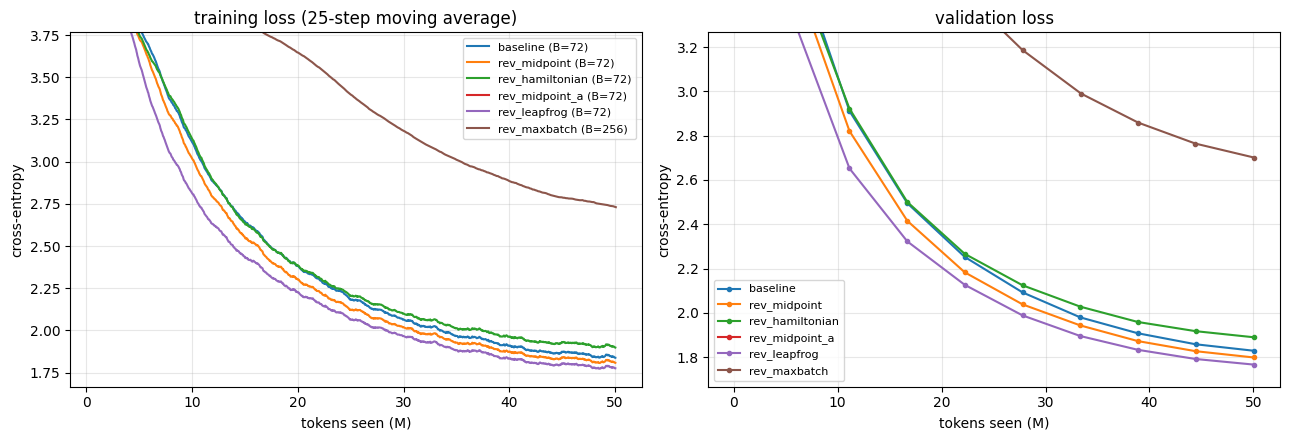

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for k, r in RUNS.items():
    tk = np.array(r["log"]["tokens"]) / 1e6; ls = np.array(r["log"]["loss"])
    w = 25; sm = np.convolve(ls, np.ones(w) / w, mode="valid") if len(ls) > w else ls
    axes[0].plot(tk[len(tk) - len(sm):], sm, label=f"{k} (B={r['batch']})")
    axes[1].plot(np.array(r["evals"]["tokens"]) / 1e6, r["evals"]["val_loss"], "o-", ms=3, label=k)
axes[0].set_title("training loss (25-step moving average)"); axes[1].set_title("validation loss")
for ax in axes:
    ax.set_xlabel("tokens seen (M)"); ax.set_ylabel("cross-entropy"); ax.grid(alpha=.3); ax.legend(fontsize=8)
lo = min(min(r["evals"]["val_loss"]) for r in RUNS.values())
axes[0].set_ylim(lo - 0.1, lo + 2.0); axes[1].set_ylim(lo - 0.1, lo + 1.5)
fig.tight_layout(); fig.savefig("assets/loss_curves.png", dpi=120); plt.show()

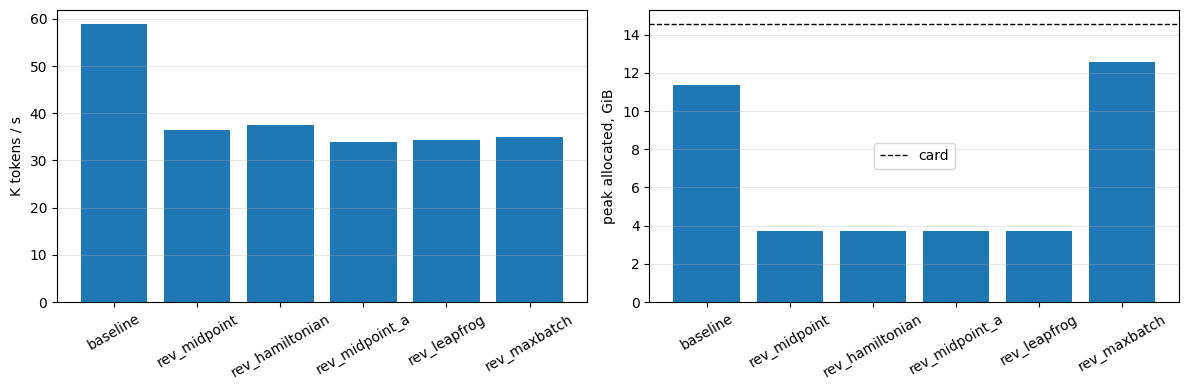

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
names = list(RUNS)
axes[0].bar(names, [RUNS[k]["tokens_per_s"] / 1e3 for k in names]); axes[0].set_ylabel("K tokens / s")
axes[1].bar(names, [RUNS[k].get("peak_alloc_gib", 0) for k in names]); axes[1].set_ylabel("peak allocated, GiB")
if DEVICE == "cuda": axes[1].axhline(ENV["gpu_mem_gib"], ls="--", c="k", lw=1, label="card"); axes[1].legend()
for ax in axes:
    ax.tick_params(axis="x", rotation=30); ax.grid(alpha=.3, axis="y")
fig.tight_layout(); fig.savefig("assets/speed_memory.png", dpi=120); plt.show()

**The compute overhead of rebuilding.** At the same batch the reversible runs do one extra
forward pass per layer. The paper estimates that as 30–50% of a step. Measured here as the
ratio of step times at the same batch:

In [24]:
OVERHEAD = {k: base["tokens_per_s"] / RUNS[k]["tokens_per_s"] - 1 for k in VARIANTS}
for k, v in OVERHEAD.items():
    print(f"{k:18s} {100*v:+.1f}% time per token vs baseline at batch {B_FIXED}")
SPEEDUP_MAX = RUNS["rev_maxbatch"]["tokens_per_s"] / base["tokens_per_s"]
print(f"\nreversible at batch {B_REV_MAX} vs baseline at {B_FIXED}: {SPEEDUP_MAX:.2f}× the throughput")

rev_midpoint       +61.4% time per token vs baseline at batch 72
rev_hamiltonian    +57.2% time per token vs baseline at batch 72
rev_midpoint_a     +73.5% time per token vs baseline at batch 72
rev_leapfrog       +71.3% time per token vs baseline at batch 72

reversible at batch 256 vs baseline at 72: 0.59× the throughput


## 12. What the trained models say about reconstruction

Gate 2 measured reconstruction at initialisation, when every block's output is small. After
training the blocks do real work, their outputs are larger, and rounding in the rebuild can
grow. Re-measure on each trained reversible model, in the fp16 autocast it trained in, and
compare the gradient the reversible backward produced with the gradient ordinary autograd
gives through the same trained weights on the same batch (cosine similarity of the full
gradient vector, and the relative error).

rev_midpoint       rebuilt-input error 1.3e-01  gradient vs oracle: cosine 0.999751, relative error 2.2e-02


rev_hamiltonian    rebuilt-input error 2.4e+00  gradient vs oracle: cosine 0.998939, relative error 4.6e-02


rev_midpoint_a     rebuilt-input error 7.0e+05  gradient vs oracle: cosine 0.008901, relative error 1.0e+00


rev_leapfrog       rebuilt-input error 1.1e-01  gradient vs oracle: cosine 0.999841, relative error 1.8e-02


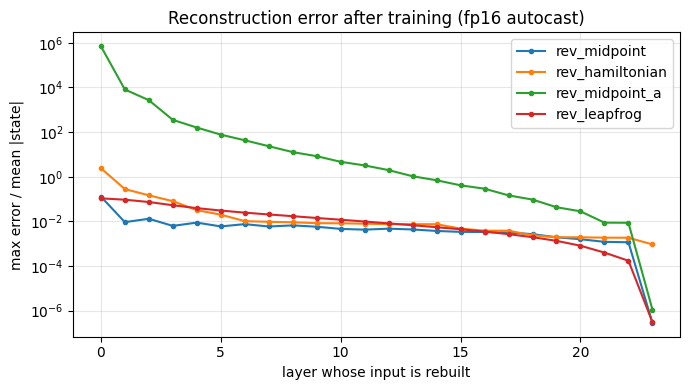

In [25]:
def grad_vs_oracle(state, rule, B=8):
    torch.manual_seed(7)
    x, y = get_batch(0, B)
    out = {}
    for store in (False, True):
        m = GPT(**CFG, rule=rule, store=store).to(DEVICE); m.load_state_dict(state)
        loss = m(x, y)[1]; loss.backward()
        out[store] = torch.cat([p.grad.float().flatten() for p in m.parameters()])
        del m
    rev, ref = out[False], out[True]
    rev, ref = rev.double(), ref.double()
    cos = F.cosine_similarity(rev, ref, dim=0).item()
    rel = ((rev - ref).norm() / ref.norm()).item()
    return cos, rel

TRAINED = {}
for k in VARIANTS:
    rule = RUNS[k]["rule"]
    m = GPT(**CFG, rule=rule).to(DEVICE); m.load_state_dict(MODELS[k]); m.eval()
    prof = recon_profile(m, probe); del m
    cos, rel = grad_vs_oracle(MODELS[k], rule)
    TRAINED[k] = {"recon_input": prof[0], "recon_max": max(prof), "profile": prof,
                  "grad_cos": cos, "grad_rel_err": rel}
    print(f"{k:18s} rebuilt-input error {prof[0]:.1e}  gradient vs oracle: cosine {cos:.6f}, "
          f"relative error {rel:.1e}")
RESULTS["trained_recon"] = {k: {kk: vv for kk, vv in v.items() if kk != "profile"} for k, v in TRAINED.items()}

fig, ax = plt.subplots(figsize=(7, 4))
for k, v in TRAINED.items():
    ax.semilogy(range(CFG["L"]), np.maximum(v["profile"], 1e-12), marker="o", ms=3, label=k)
ax.set_xlabel("layer whose input is rebuilt"); ax.set_ylabel("max error / mean |state|")
ax.set_title("Reconstruction error after training (fp16 autocast)"); ax.grid(alpha=.3); ax.legend()
fig.tight_layout(); fig.savefig("assets/recon_error_trained.png", dpi=120); plt.show()

## 13. Write results

Everything the README quotes is collected here and written once, so the write-up is filled
from measured values rather than from anything typed by hand. It is also printed between
markers so it can be recovered from the saved notebook alone.

In [26]:
def slim(r):
    return {k: v for k, v in r.items() if k not in ("log", "evals")}
RESULTS["runs"] = {k: slim(r) for k, r in RUNS.items()}
RESULTS["curves"] = {k: {"evals": r["evals"]} for k, r in RUNS.items()}
RESULTS["verdict"] = {"winner": WINNER, "winner_rule": WINNER_RULE,
                      "overhead_pct": {k: 100 * v for k, v in OVERHEAD.items()},
                      "maxbatch_speedup": SPEEDUP_MAX, "lr_maxbatch": LR_MAX,
                      "val_delta": {k: RUNS[k]["final_val_loss"] - base["final_val_loss"] for k in RUNS}}
RESULTS["meta"] = {"hourly_usd": HOURLY_USD, "total_runtime_min": (time.perf_counter() - T_START) / 60,
                   "total_cost_usd": (time.perf_counter() - T_START) / 3600 * HOURLY_USD}
if not SMOKE:
    pathlib.Path("results.json").write_text(json.dumps(RESULTS, indent=2, default=float))
print("===RESULTS-JSON-BEGIN===")
print(json.dumps(RESULTS, default=float))
print("===RESULTS-JSON-END===")
print(f"total notebook runtime {RESULTS['meta']['total_runtime_min']:.1f} min, "
      f"≈ ${RESULTS['meta']['total_cost_usd']:.2f} of GPU time")

===RESULTS-JSON-BEGIN===
{"env": {"device": "cuda", "torch": "2.5.1+cu121", "smoke": false, "python": "3.10.12", "gpu": "Tesla T4", "gpu_mem_gib": 14.56, "sm": "75"}, "data": {"dataset": "TinyStoriesV2-GPT4", "vocab": 8192, "seq_len": 512, "train_tokens_available": 55231970, "valid_tokens": 5417537, "train_budget_tokens": 50000000}, "model": {"vocab": 8192, "d": 256, "L": 24, "heads": 4, "T": 512, "params": 21182976, "params_M": 21.182976, "params_blocks_M": 18.954752, "h": 0.25, "a": 0.5, "dropout": 0.0, "weight_decay": 0.0}, "gate1": {"midpoint": {"loss_diff": 0.0, "max_rel_grad_diff": 2.197848362643278e-16}, "midpoint_a": {"loss_diff": 0.0, "max_rel_grad_diff": 4.275265392062961e-09}, "leapfrog": {"loss_diff": 0.0, "max_rel_grad_diff": 3.4113471664306058e-15}, "hamiltonian": {"loss_diff": 0.0, "max_rel_grad_diff": 2.1339016675089095e-16}}, "gate2_init": {"midpoint": {"fp32": {"input": 3.957236780273438e-06, "max": 3.957236780273438e-06}, "fp16": {"input": 0.004389894668250001, "max"